# Full Pair Comparison

Runs 81 total variants across the three requested pair-comparison cases. Each case sweeps scenarios 1-3, robust epsilon starts `0.25`, `0.5`, `1.0`, and epsilon schedules `linear`, `exponential`, `constant`.

In [1]:
from pathlib import Path
import dataclasses
import sys

notebook_dir = Path.cwd()
if notebook_dir.name != "bimatrix_game":
    candidate = notebook_dir / "discrete_action_space" / "bimatrix_game"
    if candidate.exists():
        notebook_dir = candidate.resolve()

for path in (notebook_dir, notebook_dir.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from experiment_harness import (
    BASE_SEED,
    DEEP_SRQ_HYPERPARAMS,
    SCENARIO_CONFIGS,
    configure_path_runtime,
    save_training_stats,
    train_pairing,
)
from vectorized_deep_srq import train_vectorized_deep_srq_experiment
from stats_utils import load_training_stats

discrete_action_space_dir = notebook_dir.parent
pathwrap_path = Path(configure_path_runtime(discrete_action_space_dir)).resolve()
if not pathwrap_path.exists():
    raise FileNotFoundError(f"PATH solver library not found at {pathwrap_path}")


In [2]:
def run_pair_epsilon_sweep(
    *,
    pairing,
    case_slug,
    case_seed_offset,
    scenarios,
    scenario_configs,
    epsilon_starts,
    epsilon_schedules,
    n_episodes,
    base_seed,
    output_root,
    use_gpu,
    write_plots,
    base_hyperparameters,
    hyperparameter_overrides,
    vectorized_num_envs=None,
):
    results = {}
    case_output_root = Path(output_root) / case_slug
    use_vectorized_self_play = (
        tuple(pairing) == ("deep_srq", "deep_srq")
        and vectorized_num_envs is not None
        and int(vectorized_num_envs) > 1
    )

    def variant_stats_path(scenario_key, epsilon_start, epsilon_schedule, variant_key, seed):
        if use_vectorized_self_play:
            run_name = f"vectorized_envs{int(vectorized_num_envs)}_eps{float(epsilon_start):g}_{epsilon_schedule}__{variant_key}_{seed}"
            return case_output_root / scenario_key / run_name / "training_stats.txt"
        run_slug_parts = []
        for algorithm in pairing:
            if algorithm == "nashq":
                run_slug_parts.append("nashq")
            else:
                run_slug_parts.append(
                    f"{algorithm}_{epsilon_schedule}_eps{float(epsilon_start):g}"
                )
        run_slug = "_vs_".join(run_slug_parts)
        run_slug = f"{run_slug}_{variant_key}_{seed}"
        return case_output_root / scenario_key / run_slug / "training_stats.txt"

    for scenario_index, scenario_key in enumerate(scenarios):
        scenario_config = scenario_configs[scenario_key]
        scenario_results = {}

        for schedule_index, epsilon_schedule in enumerate(epsilon_schedules):
            for epsilon_index, epsilon_start in enumerate(epsilon_starts):
                seed = (
                    base_seed
                    + case_seed_offset
                    + scenario_index * 1000
                    + schedule_index * 100
                    + epsilon_index
                )
                variant_key = f"eps{epsilon_start:g}_{epsilon_schedule}"
                hyperparameters = dataclasses.replace(
                    base_hyperparameters,
                    **hyperparameter_overrides,
                    epsilon_robust=float(epsilon_start),
                    epsilon_robust_initial=float(epsilon_start),
                    epsilon_schedule=epsilon_schedule,
                )
                epsilon_robust_initials = tuple(
                    None if algorithm == "nashq" else float(epsilon_start)
                    for algorithm in pairing
                )
                per_agent_schedules = tuple(
                    None if algorithm == "nashq" else epsilon_schedule
                    for algorithm in pairing
                )

                stats_path = variant_stats_path(
                    scenario_key,
                    epsilon_start,
                    epsilon_schedule,
                    variant_key,
                    seed,
                )
                if stats_path.exists():
                    stats = load_training_stats(stats_path)
                    print(f"Skipping existing run: {stats_path}")
                elif use_vectorized_self_play:
                    stats = train_vectorized_deep_srq_experiment(
                        scenario_key=scenario_key,
                        scenario_config=scenario_config,
                        n_episodes=n_episodes,
                        num_envs=int(vectorized_num_envs),
                        seed=seed,
                        output_root=case_output_root,
                        use_gpu=use_gpu,
                        write_plots=write_plots,
                        hyperparameters=hyperparameters,
                        run_name_suffix=f"{variant_key}_{seed}",
                        print_full_stats=False,
                    )
                else:
                    stats = train_pairing(
                        scenario_key=scenario_key,
                        scenario_config=scenario_config,
                        pairing=pairing,
                        n_episodes=n_episodes,
                        seed=seed,
                        output_root=case_output_root,
                        use_gpu=use_gpu,
                        write_plots=write_plots,
                        hyperparameters=hyperparameters,
                        epsilon_robust_initials=epsilon_robust_initials,
                        epsilon_schedules=per_agent_schedules,
                        run_name_suffix=variant_key,
                        include_episode_durations=False,
                        print_full_stats=False,
                    )
                stats["case_slug"] = case_slug
                stats["variant_key"] = variant_key
                stats["case_seed_offset"] = int(case_seed_offset)
                scenario_results[variant_key] = stats

        results[scenario_key] = scenario_results

    return results


In [ ]:
scenarios = ("scenario1", "scenario2", "scenario3")
epsilon_starts = (0.25, 0.5, 1.0)
epsilon_schedules = ("linear", "exponential", "constant")

solver_name = "path_c_pool"
network_type = "joint_output"
n_episodes = 3000
num_envs = 32
batch_size = 16
target_update = 100
use_gpu = True
write_plots = True

scenario_configs = SCENARIO_CONFIGS
base_hyperparameters = DEEP_SRQ_HYPERPARAMS

# Applied only to Deep SRQ agents. Tabular SRQ/NashQ use their own configs.
deep_srq_hyperparameter_overrides = {
    "batch_size": batch_size,
    "gamma": 0.9,
    "train_every": 4,
    "target_update_steps": target_update,
    "target_equilibrium_update_steps": 1,
    "sre_solver_name": solver_name,
    "sre_num_repeats": 5,
    "sre_include_pure_starts": True,
    "network_type": network_type,
    "sre_solver_workers": 8,
    "sre_solver_start_method": None,
    "sre_policy_cache_enabled": False,
    "sre_candidate_selection": "joint_nominal_welfare",
    "sre_exploitability_filter_enabled": False,
    "sre_approx_cache_enabled": False,
}

full_pair_output_root = Path("full_pair_comparison_runs")

common_sweep_kwargs = {
    "scenarios": scenarios,
    "scenario_configs": scenario_configs,
    "epsilon_starts": epsilon_starts,
    "epsilon_schedules": epsilon_schedules,
    "n_episodes": n_episodes,
    "base_seed": BASE_SEED,
    "output_root": full_pair_output_root,
    "use_gpu": use_gpu,
    "write_plots": write_plots,
    "base_hyperparameters": base_hyperparameters,
    "hyperparameter_overrides": deep_srq_hyperparameter_overrides,
    "vectorized_num_envs": num_envs,
}


## Deep SRQ vs Deep SRQ

Skipping existing run: full_pair_comparison_runs/deep_srq_vs_deep_srq/scenario1/vectorized_envs32_eps0.25_linear__eps0.25_linear_2025/training_stats.txt


scenario1:vectorized_envs32_eps0.5_linear__eps0.5_linear_2026: 100%|██████████████| 3000/3000 [1:07:27<00:00,  1.35s/it]


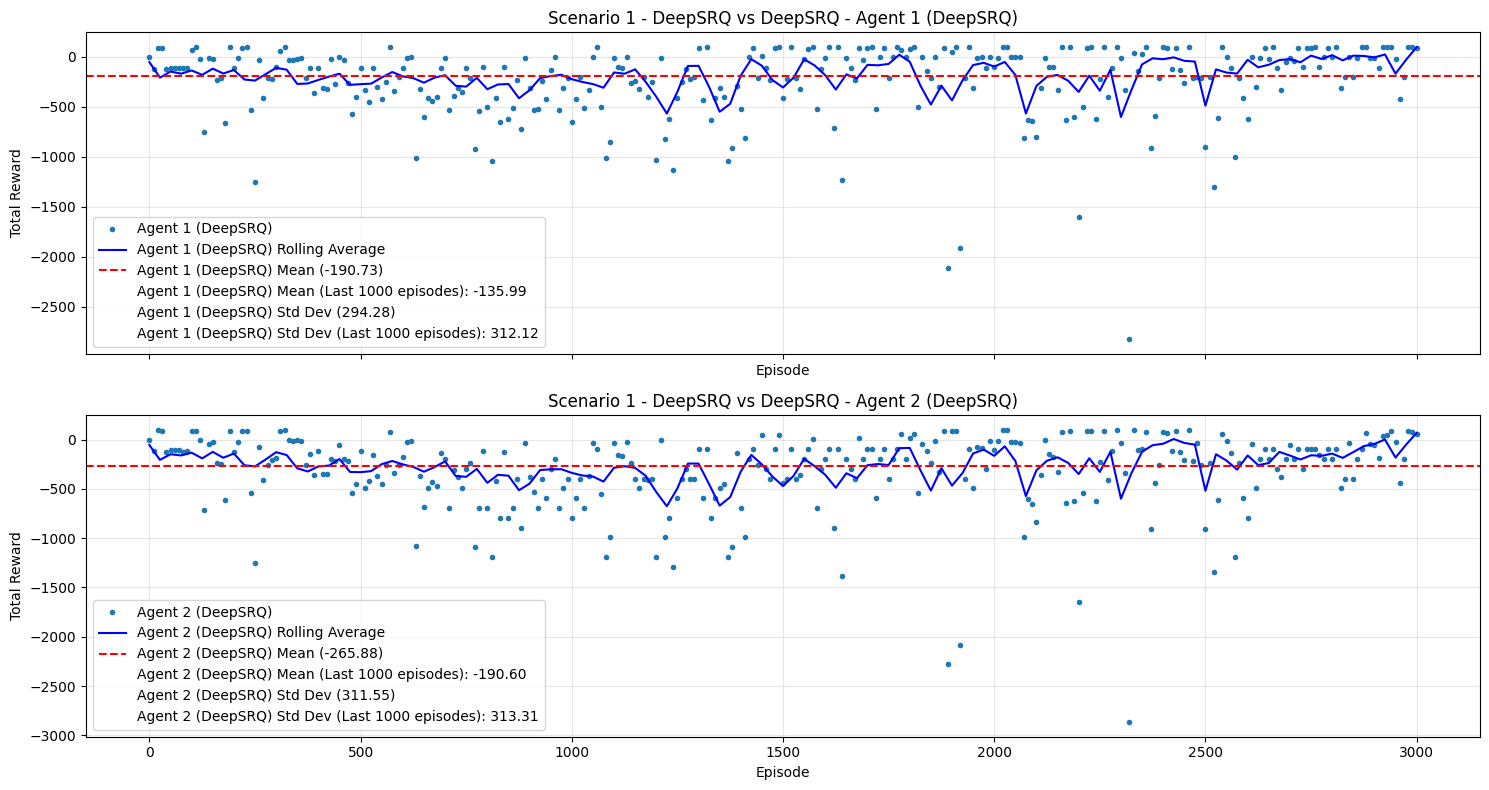

Scenario 1 - vectorized DeepSRQ
Wall clock: 4013.261s (66.89 min)
Episode time:   count=0
SRE solve time: count=491176, mean=0.004259s (4258.55 us), min=0.001177s, max=0.078172s, std=0.002344s
Backend solve:  count=491176, mean=0.018519s (18518.99 us), min=0.006293s, max=0.393269s, std=0.011230s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=491176, mean=0.004259s (4258.55 us), min=0.001177s, max=0.078172s, std=0.002344s
    Backend:    count=491176, mean=0.018519s (18518.99 us), min=0.006293s, max=0.393269s, std=0.011230s
    Update:     count=199353, mean=0.018196s (18195.85 us), min=0.004004s, max=0.942357s, std=0.018267s

Reward Summary
Scenario   | Pair               | Agent             | Mean    | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+---------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -190.73 | 294.28 | -135.99          | 312.12   

scenario1:vectorized_envs32_eps1_linear__eps1_linear_2027: 100%|████████████████████| 3000/3000 [47:06<00:00,  1.06it/s]


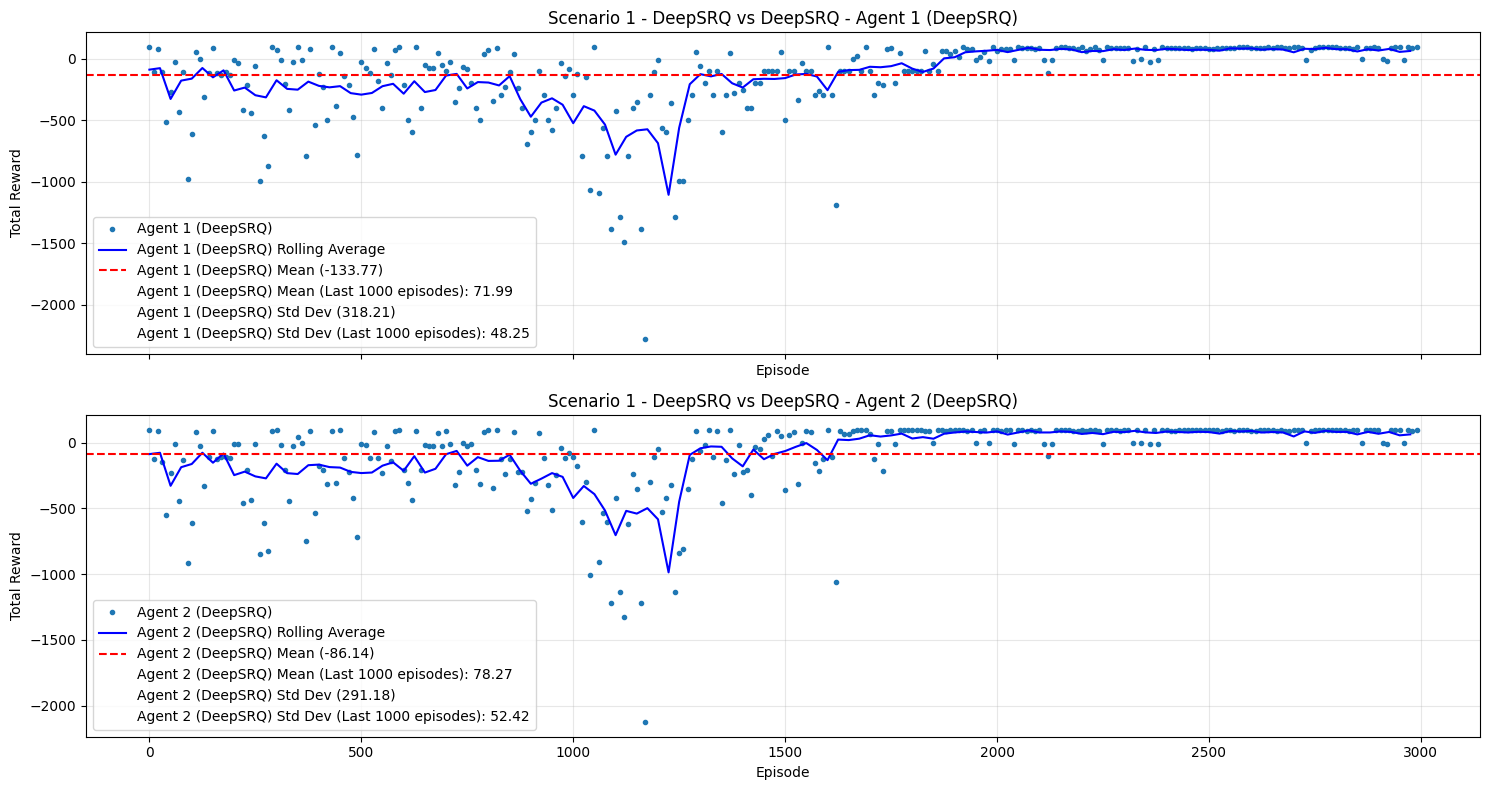

Scenario 1 - vectorized DeepSRQ
Wall clock: 2772.287s (46.20 min)
Episode time:   count=0
SRE solve time: count=391476, mean=0.003518s (3517.55 us), min=0.001385s, max=0.095096s, std=0.001574s
Backend solve:  count=391476, mean=0.016199s (16198.78 us), min=0.006486s, max=0.320812s, std=0.008232s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=391476, mean=0.003518s (3517.55 us), min=0.001385s, max=0.095096s, std=0.001574s
    Backend:    count=391476, mean=0.016199s (16198.78 us), min=0.006486s, max=0.320812s, std=0.008232s
    Update:     count=142969, mean=0.017423s (17423.03 us), min=0.004394s, max=0.487362s, std=0.016199s

Reward Summary
Scenario   | Pair               | Agent             | Mean    | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+---------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -133.77 | 318.21 | 71.99            | 48.25    

scenario1:vectorized_envs32_eps0.25_exponential__eps0.25_exponential_2125: 100%|████| 3000/3000 [50:19<00:00,  1.01s/it]


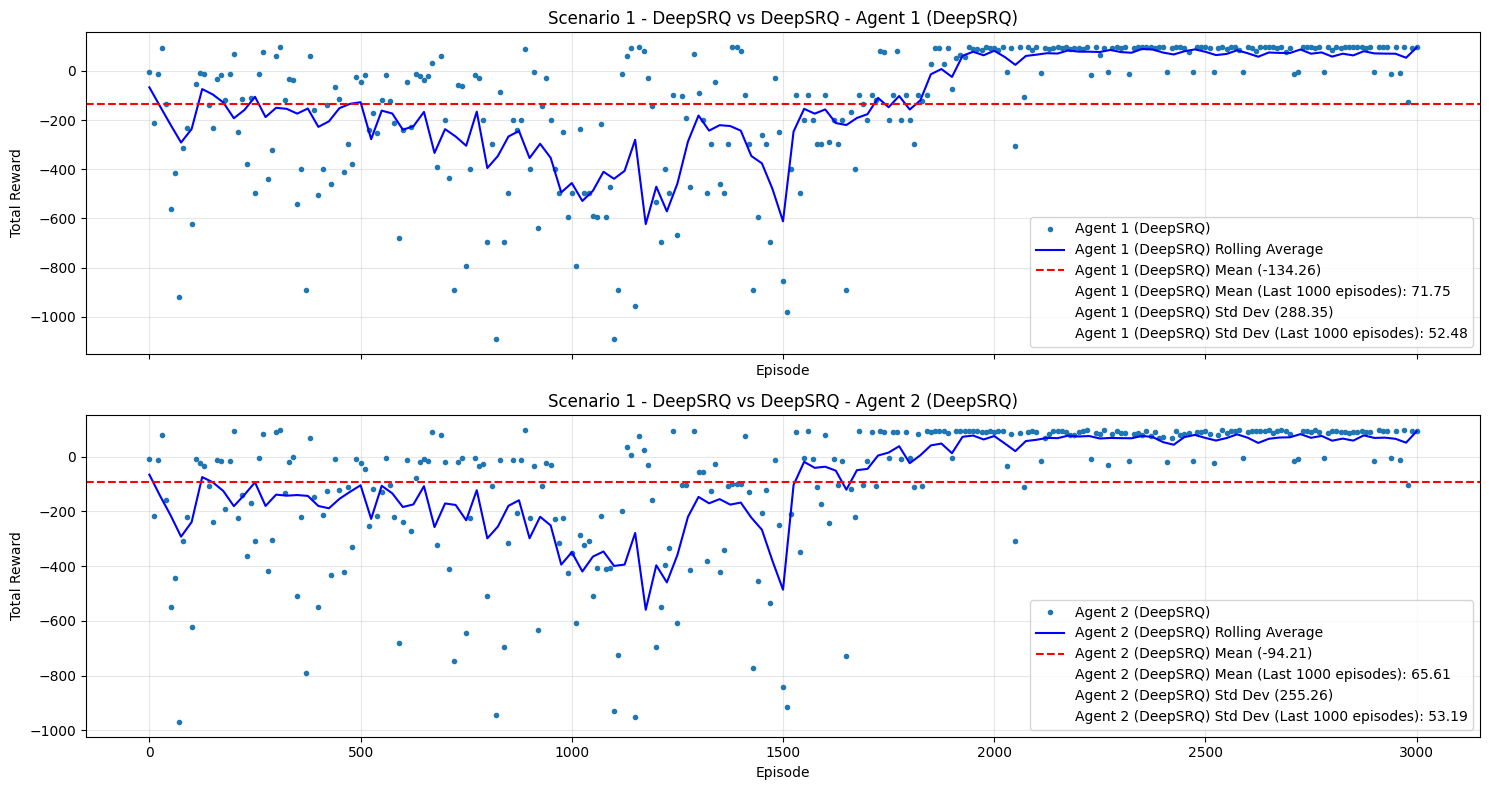

Scenario 1 - vectorized DeepSRQ
Wall clock: 2979.341s (49.66 min)
Episode time:   count=0
SRE solve time: count=400865, mean=0.003867s (3866.77 us), min=0.001340s, max=0.087699s, std=0.001952s
Backend solve:  count=400865, mean=0.017586s (17586.28 us), min=0.006312s, max=0.284506s, std=0.010711s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=400865, mean=0.003867s (3866.77 us), min=0.001340s, max=0.087699s, std=0.001952s
    Backend:    count=400865, mean=0.017586s (17586.28 us), min=0.006312s, max=0.284506s, std=0.010711s
    Update:     count=143481, mean=0.018754s (18753.72 us), min=0.004297s, max=0.306045s, std=0.019120s

Reward Summary
Scenario   | Pair               | Agent             | Mean    | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+---------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -134.26 | 288.35 | 71.75            | 52.48    

scenario1:vectorized_envs32_eps0.5_exponential__eps0.5_exponential_2126: 100%|██████| 3000/3000 [31:57<00:00,  1.56it/s]


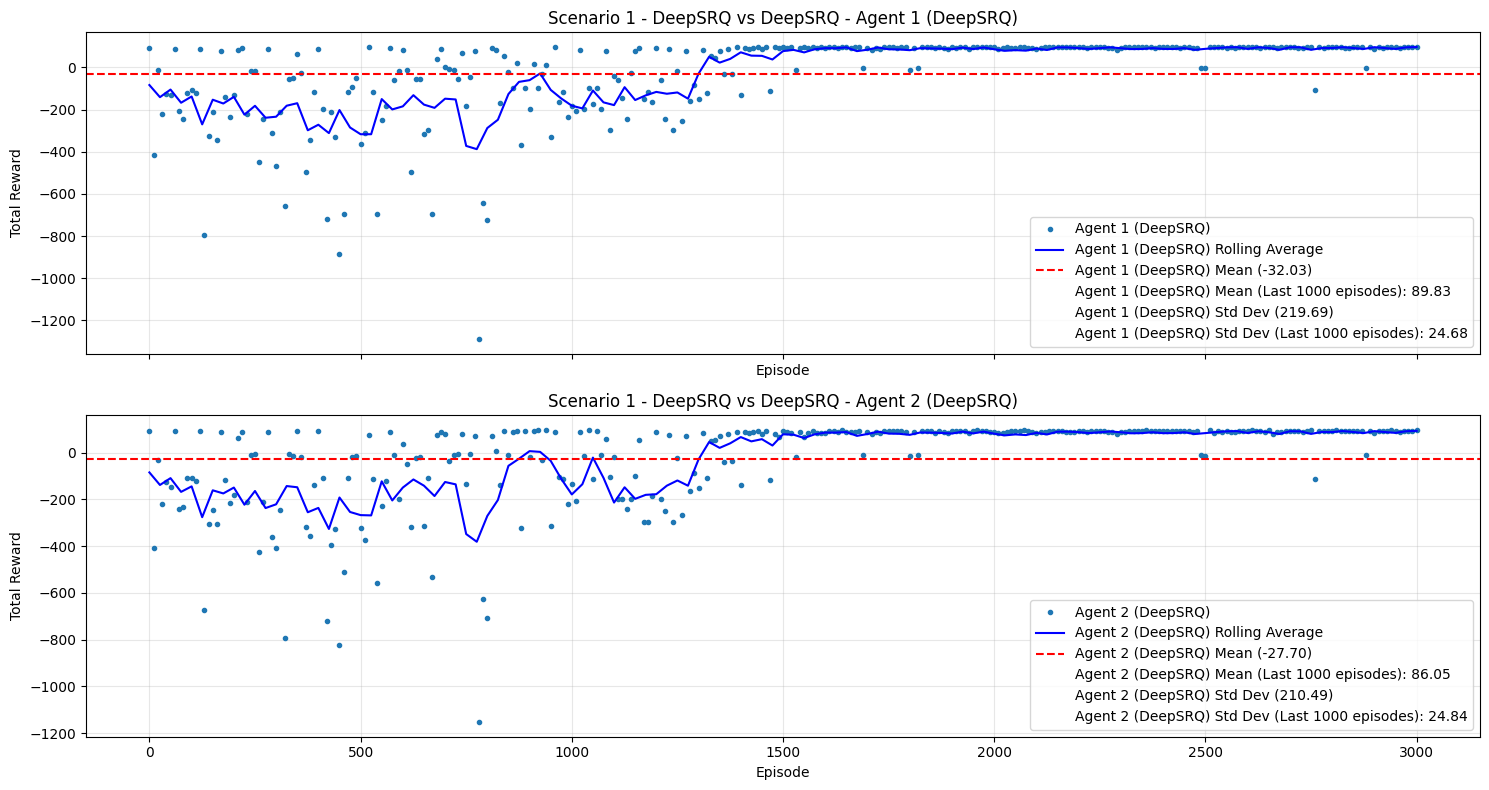

Scenario 1 - vectorized DeepSRQ
Wall clock: 1877.410s (31.29 min)
Episode time:   count=0
SRE solve time: count=312348, mean=0.002965s (2965.02 us), min=0.001333s, max=0.034396s, std=0.000948s
Backend solve:  count=312348, mean=0.014782s (14782.42 us), min=0.006936s, max=0.282084s, std=0.006219s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=312348, mean=0.002965s (2965.02 us), min=0.001333s, max=0.034396s, std=0.000948s
    Backend:    count=312348, mean=0.014782s (14782.42 us), min=0.006936s, max=0.282084s, std=0.006219s
    Update:     count=95545, mean=0.017549s (17548.73 us), min=0.004752s, max=0.301147s, std=0.015253s

Reward Summary
Scenario   | Pair               | Agent             | Mean   | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+--------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -32.03 | 219.69 | 89.83            | 24.68        

scenario1:vectorized_envs32_eps1_exponential__eps1_exponential_2127: 100%|██████████| 3000/3000 [59:32<00:00,  1.19s/it]


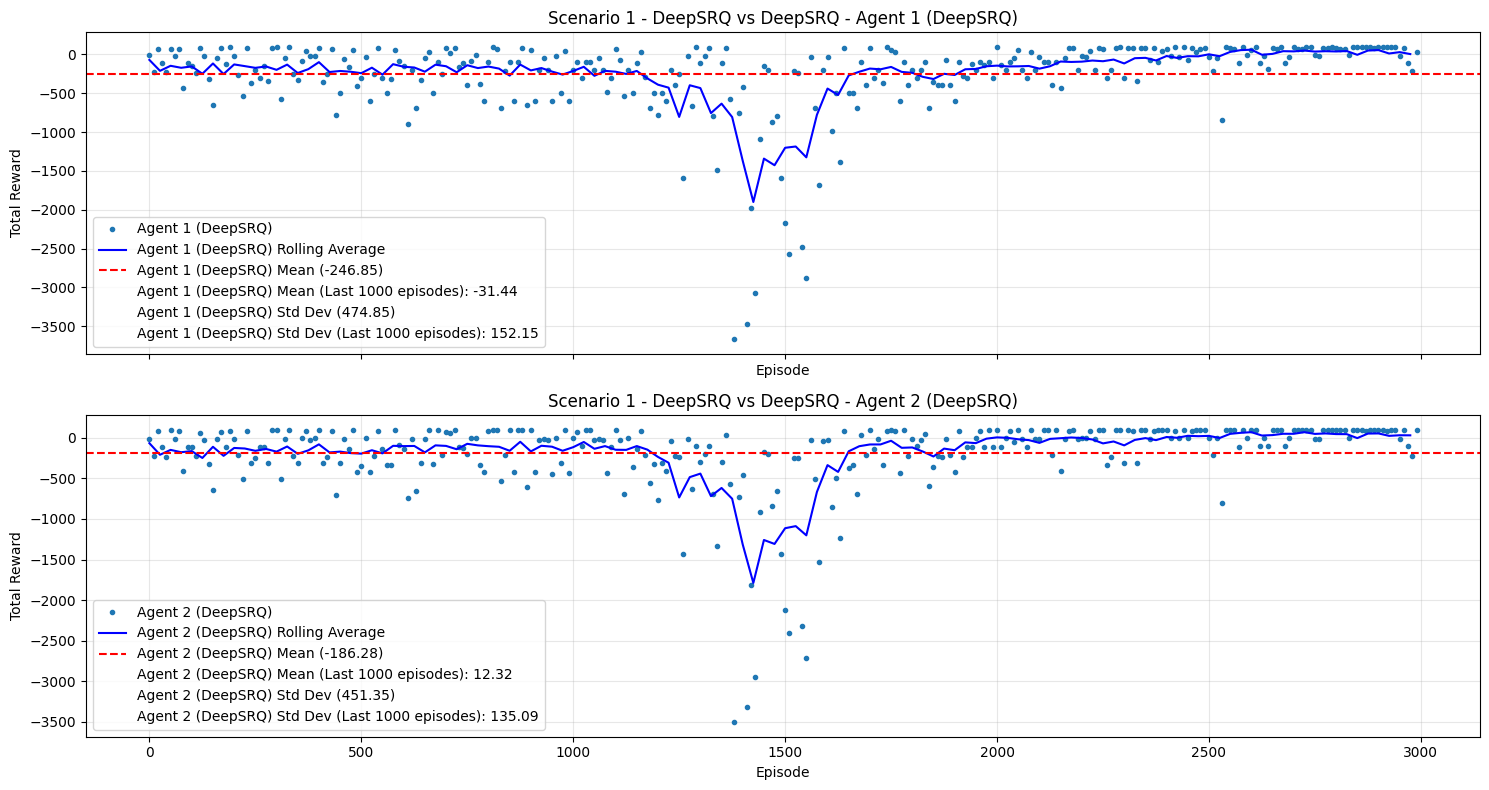

Scenario 1 - vectorized DeepSRQ
Wall clock: 3507.820s (58.46 min)
Episode time:   count=0
SRE solve time: count=464404, mean=0.003873s (3872.51 us), min=0.001307s, max=0.064858s, std=0.001865s
Backend solve:  count=464404, mean=0.017429s (17429.19 us), min=0.006275s, max=0.310464s, std=0.010442s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=464404, mean=0.003873s (3872.51 us), min=0.001307s, max=0.064858s, std=0.001865s
    Backend:    count=464404, mean=0.017429s (17429.19 us), min=0.006275s, max=0.310464s, std=0.010442s
    Update:     count=175097, mean=0.018084s (18083.90 us), min=0.004450s, max=0.321090s, std=0.017669s

Reward Summary
Scenario   | Pair               | Agent             | Mean    | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+---------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -246.85 | 474.85 | -31.44           | 152.15   

scenario1:vectorized_envs32_eps0.25_constant__eps0.25_constant_2225: 100%|██████████| 3000/3000 [42:51<00:00,  1.17it/s]


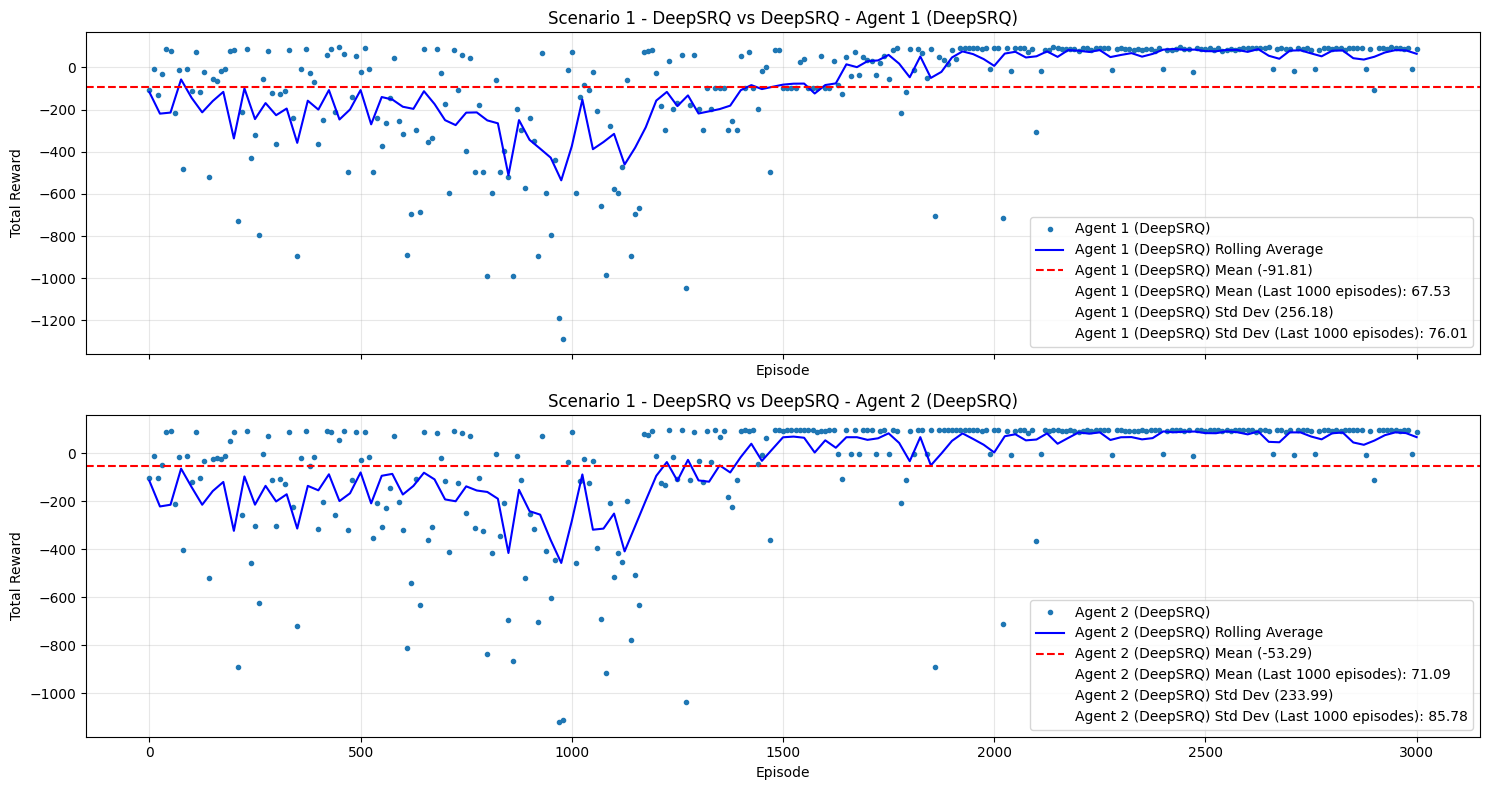

Scenario 1 - vectorized DeepSRQ
Wall clock: 2511.271s (41.85 min)
Episode time:   count=0
SRE solve time: count=350305, mean=0.003607s (3607.12 us), min=0.001403s, max=0.048072s, std=0.001766s
Backend solve:  count=350305, mean=0.016236s (16236.28 us), min=0.006718s, max=0.336742s, std=0.008990s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=350305, mean=0.003607s (3607.12 us), min=0.001403s, max=0.048072s, std=0.001766s
    Backend:    count=350305, mean=0.016236s (16236.28 us), min=0.006718s, max=0.336742s, std=0.008990s
    Update:     count=129529, mean=0.017415s (17414.82 us), min=0.004334s, max=0.293090s, std=0.016882s

Reward Summary
Scenario   | Pair               | Agent             | Mean   | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+--------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -91.81 | 256.18 | 67.53            | 76.01       

scenario1:vectorized_envs32_eps0.5_constant__eps0.5_constant_2226: 100%|████████████| 3000/3000 [32:39<00:00,  1.53it/s]


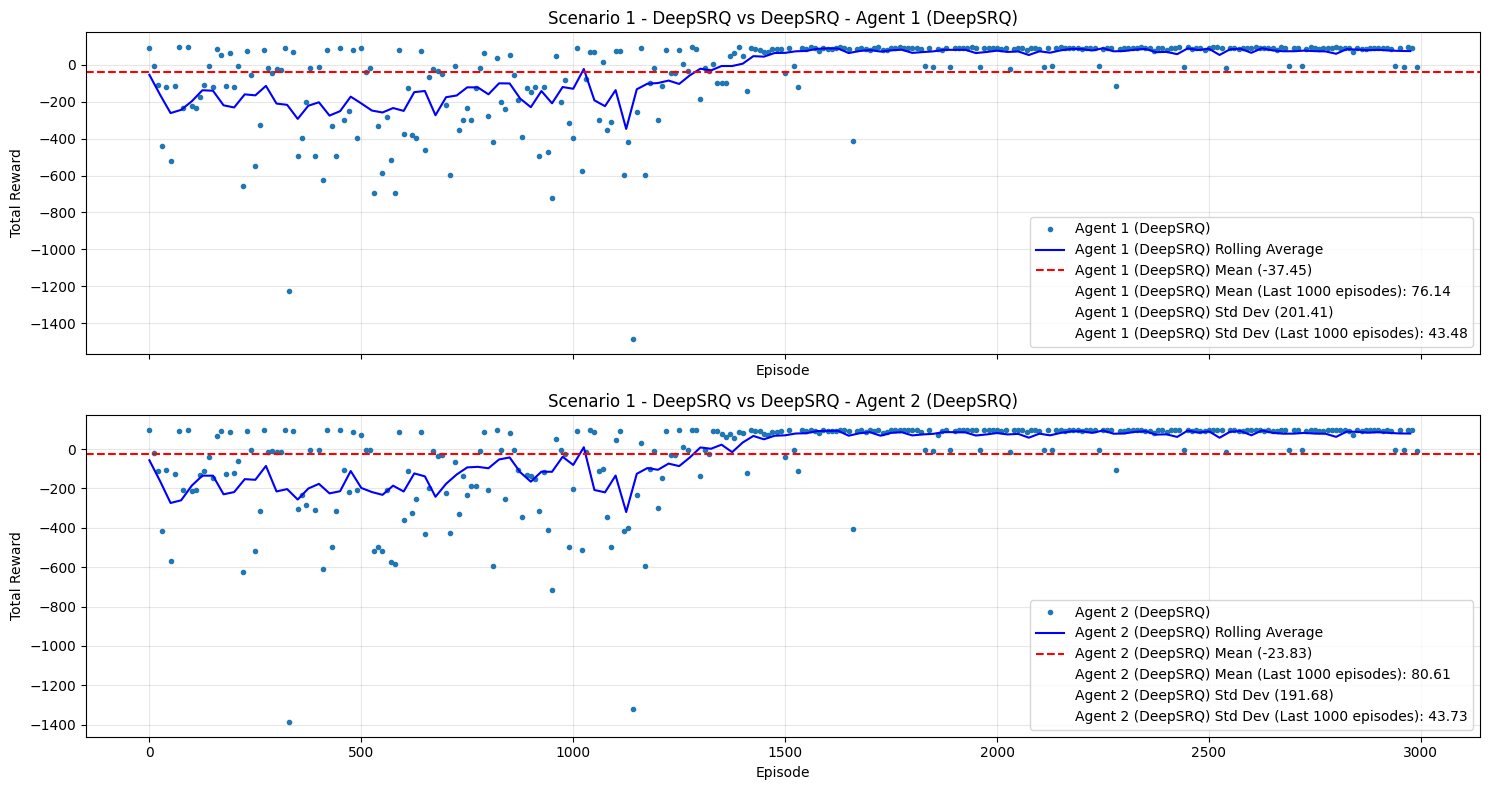

Scenario 1 - vectorized DeepSRQ
Wall clock: 1906.339s (31.77 min)
Episode time:   count=0
SRE solve time: count=323186, mean=0.002869s (2869.02 us), min=0.001452s, max=0.027986s, std=0.000922s
Backend solve:  count=323186, mean=0.014248s (14248.00 us), min=0.007309s, max=0.286843s, std=0.005977s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=323186, mean=0.002869s (2869.02 us), min=0.001452s, max=0.027986s, std=0.000922s
    Backend:    count=323186, mean=0.014248s (14248.00 us), min=0.007309s, max=0.286843s, std=0.005977s
    Update:     count=100089, mean=0.017016s (17015.90 us), min=0.005164s, max=0.298810s, std=0.014641s

Reward Summary
Scenario   | Pair               | Agent             | Mean   | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+--------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -37.45 | 201.41 | 76.14            | 43.48       

scenario1:vectorized_envs32_eps1_constant__eps1_constant_2227: 100%|████████████████| 3000/3000 [25:31<00:00,  1.96it/s]


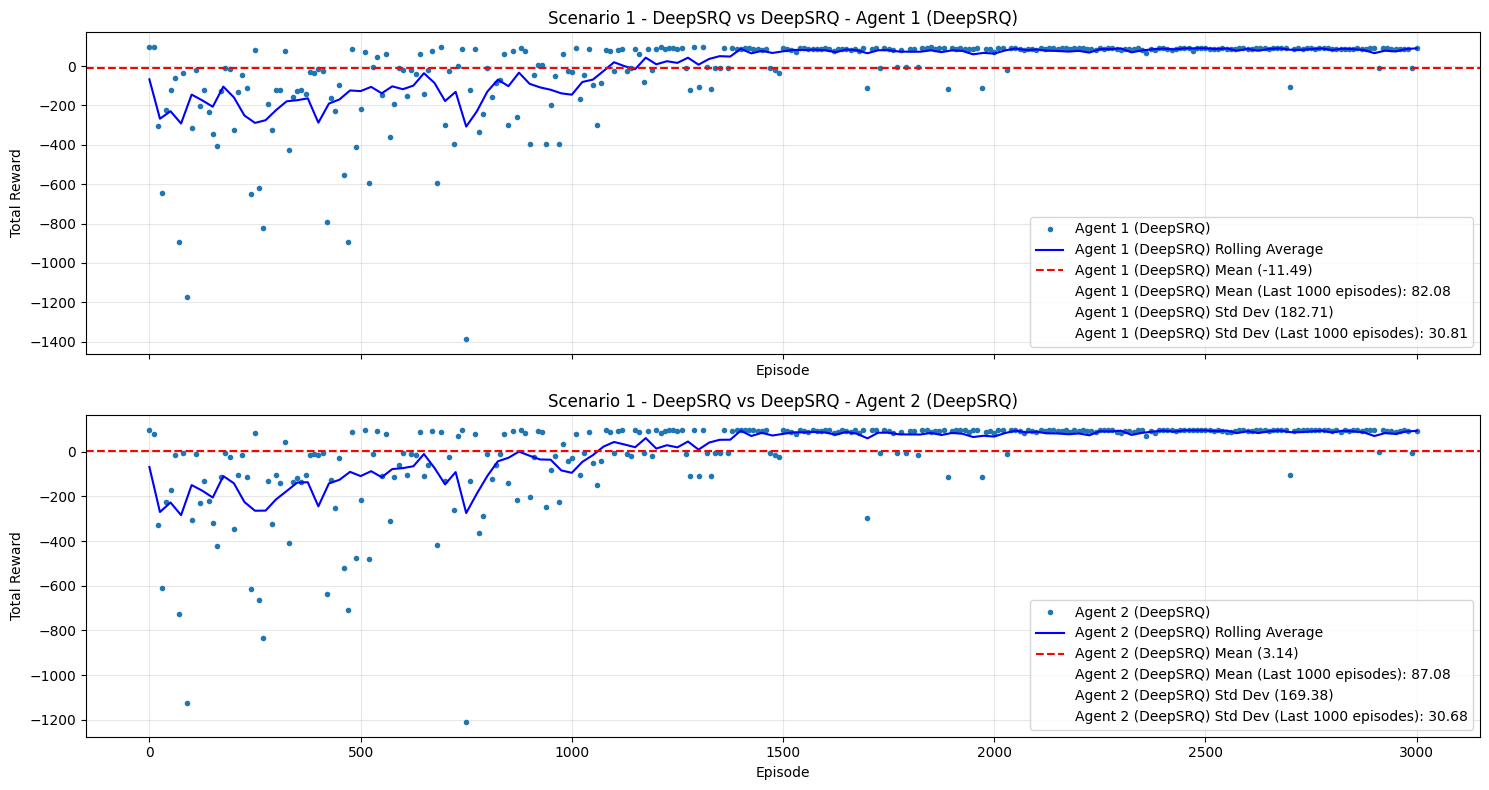

Scenario 1 - vectorized DeepSRQ
Wall clock: 1486.773s (24.78 min)
Episode time:   count=0
SRE solve time: count=259307, mean=0.002679s (2679.16 us), min=0.001436s, max=0.030228s, std=0.000786s
Backend solve:  count=259307, mean=0.013283s (13283.15 us), min=0.007253s, max=0.102616s, std=0.005398s
  Agent 0 (DuelingDoubleDqnSreAgent)
    SRE solve:  count=259307, mean=0.002679s (2679.16 us), min=0.001436s, max=0.030228s, std=0.000786s
    Backend:    count=259307, mean=0.013283s (13283.15 us), min=0.007253s, max=0.102616s, std=0.005398s
    Update:     count=81241, mean=0.016357s (16356.64 us), min=0.005022s, max=0.112057s, std=0.013350s

Reward Summary
Scenario   | Pair               | Agent             | Mean   | Std    | Mean (Last 1000) | Std (Last 1000) | Episodes
-----------+--------------------+-------------------+--------+--------+------------------+-----------------+---------
Scenario 1 | DeepSRQ vs DeepSRQ | Agent 1 (DeepSRQ) | -11.49 | 182.71 | 82.08            | 30.81        

scenario2:vectorized_envs32_eps0.25_linear__eps0.25_linear_3025:   5%|▋              | 149/3000 [01:37<34:14,  1.39it/s]

In [ ]:
deep_srq_vs_deep_srq_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "deep_srq"),
    case_slug="deep_srq_vs_deep_srq",
    case_seed_offset=0,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_deep_srq_manifest.txt",
    deep_srq_vs_deep_srq_results,
)


## Deep SRQ vs Tabular SRQ

In [ ]:
deep_srq_vs_tabular_srq_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "srq"),
    case_slug="deep_srq_vs_tabular_srq",
    case_seed_offset=10_000,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_tabular_srq_manifest.txt",
    deep_srq_vs_tabular_srq_results,
)


## Deep SRQ vs Nash Q

In [ ]:
deep_srq_vs_nash_q_results = run_pair_epsilon_sweep(
    pairing=("deep_srq", "nashq"),
    case_slug="deep_srq_vs_nash_q",
    case_seed_offset=20_000,
    **common_sweep_kwargs,
)

save_training_stats(
    full_pair_output_root / "deep_srq_vs_nash_q_manifest.txt",
    deep_srq_vs_nash_q_results,
)
